### Build a basic ChatBot with Langgraph using Graph API

In [44]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
load_dotenv()
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")
# os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


In [45]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
 
llm = ChatGroq(model="qwen/qwen3-32b")



In [46]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [47]:
graph_builder = StateGraph(State)

#add nodes
graph_builder.add_node("llmchatbot",chatbot)

##adding edges between nodes

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

print(graph_builder)


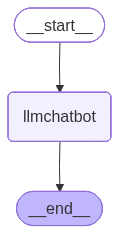

In [48]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [49]:
2==2

True

In [50]:
response = graph.invoke({"messages":"HI I'm Yogesh"})
print(response["messages"][-1].content)

<think>
Okay, the user just introduced themselves as Yogesh. I should acknowledge their greeting and offer assistance. Let me keep it friendly and open-ended.

First, I'll say hello and welcome them. Then, I'll ask how I can help. Maybe add an emoji to keep it approachable. Let me check for any typos and make sure the tone is positive. Alright, that should do it.
</think>

Hello Yogesh! 👋 Nice to meet you. How can I assist you today? Whether it's a question, a topic you'd like to discuss, or something else, I'm here to help! 😊


In [51]:
for event in graph.stream({"messages":["Hi How are you?","Please add 2+2", "I want to know your name"]}):
    for value in event.values():
        print("--------")
        print(value["messages"][-1].content)

--------
<think>
Okay, the user asked for my name. Let me check the previous messages to see if I've mentioned it before. In the first response, I introduced myself as Qwen. The user then asked to add 2+2 and got the answer 4. Now they're asking for my name again.

I should confirm my name again but maybe add a bit more context this time. Since they're asking again, maybe they want to know more or just forgot. I'll state my name clearly and mention that I'm a large language model developed by Alibaba Cloud. Also, I can offer help with various tasks. Keep it friendly and open-ended so they feel comfortable asking more questions.
</think>

My name is **Qwen**, and I'm a large language model developed by Alibaba Cloud. How can I assist you today? 😊


## Chatbot with TOOL 🤖

In [52]:

from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=2)

def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

tools=[tool,multiply]
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

    

_ChatModelBinding(bound=ChatGroq(metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.7'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10ef42d50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ef43ed0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accura

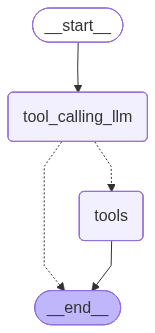

In [53]:
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
def tool_calling_llm(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)

builder.add_edge("tools", END)

graph= builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [54]:
response=graph.invoke({"messages":"current time in delhi,india"})

In [55]:
response['messages'][-1].content

"No search results found for 'current time in Delhi, India'. Suggestions: Remove time_range argument, Try a more detailed search using 'advanced' search_depth. Try modifying your search parameters with one of these approaches."

In [56]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

current time in delhi,india
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2qsvhdjks)
 Call ID: 2qsvhdjks
  Args:
    query: current time in Delhi, India
    time_range: day
    topic: general
================================= Tool Message =================================
Name: tavily_search

No search results found for 'current time in Delhi, India'. Suggestions: Remove time_range argument, Try a more detailed search using 'advanced' search_depth. Try modifying your search parameters with one of these approaches.


In [57]:
response=graph.invoke({"messages":"what is recent khan sir news on media?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is recent khan sir news on media?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (r5h2xct09)
 Call ID: r5h2xct09
  Args:
    query: Khan Sir news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Khan Sir news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://boxingnews.com/news/press-conf-khans-legacy-inspired-a-generation-of-south-asian-boxers", "title": "Khan's legacy inspired a generation of South Asian boxers - boxingnews.com", "score": 1.0, "published_date": "Mon, 08 Jun 2026 00:02:44 GMT", "content": "Khan's legacy inspired a generation of South Asian boxersKhan's legacy inspired a generation of South Asian boxers. # Khan's legacy inspired a generation of South Asian boxers. Abdul Khan says Amir

## ReAct Agent Architecture 

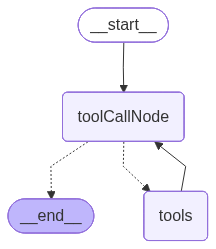

In [58]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
def toolCallNode(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

# nodes
nodeBuilder = StateGraph(State)
##adding nodes
nodeBuilder.add_node("toolCallNode",toolCallNode)
nodeBuilder.add_node("tools",ToolNode(tools))

## adding edges

nodeBuilder.add_edge(START,"toolCallNode")
nodeBuilder.add_conditional_edges("toolCallNode",tools_condition)
nodeBuilder.add_edge("tools","toolCallNode")

newGraph = nodeBuilder.compile() 
from IPython.display import Image, display
display(Image(newGraph.get_graph().draw_mermaid_png()))

In [59]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (0tdjgt38p)
 Call ID: 0tdjgt38p
  Args:
    include_images: True
    query: recent AI news
    search_depth: advanced
    time_range: week
  multiply (1wsh24dq4)
 Call ID: 1wsh24dq4
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": ["https://vilmate.com/wp-content/uploads/2024/10/latest-updates-o-AI.png.webp", "https://www.rollingstone.com/wp-content/uploads/2023/12/AI-newsroom.jpg?w=1581&h=1054&crop=1", "https://cdn.prod.website-files.com/67166bf779ba8852260f7d1f/694a731a76c9d6876ddf8a8f_latest-ai-news-and-updates.png"], "results": [{"url": "https://blog.google/innovation-and-ai/technol

### Adding MemoryIn Agentic Graph

In [62]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
def toolCallNode(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

# nodes
nodeBuilder = StateGraph(State)
##adding nodes
nodeBuilder.add_node("toolCallNode",toolCallNode)
nodeBuilder.add_node("tools",ToolNode(tools))

## adding edges

nodeBuilder.add_edge(START,"toolCallNode")
nodeBuilder.add_conditional_edges("toolCallNode",tools_condition)
nodeBuilder.add_edge("tools","toolCallNode")

newGraph = nodeBuilder.compile(checkpointer=memory) 


config={"configurable":{"thread_id":"1"}}

response = newGraph.invoke({"messages":"Hey, My Name is Yogesh"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey, My Name is Yogesh
================================== Ai Message ==================================

Hello Yogesh! Nice to meet you. How can I assist you today? 😊


In [63]:
response = newGraph.invoke({"messages":"what is my name?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey, My Name is Yogesh
================================== Ai Message ==================================

Hello Yogesh! Nice to meet you. How can I assist you today? 😊
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Yogesh. Let me know how I can assist you! 😊


In [65]:
response = newGraph.invoke({"messages":"Hey, My Name is Sumit?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey, My Name is Yogesh
================================== Ai Message ==================================

Hello Yogesh! Nice to meet you. How can I assist you today? 😊
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Yogesh. Let me know how I can assist you! 😊
================================ Human Message =================================

Hey, My Name is Age?
================================== Ai Message ==================================

Hello Age! Let me confirm - you previously introduced yourself as Yogesh. Was this a typo or would you like me to use the name Age moving forward? 😊
================================ Human Message =================================

Hey, My Name is Sumit?
================================== Ai Message ============================